# Phase 2: 高度な異常検出手法

Phase 1（twins-data-eda.ipynb）の11手法に加え、以下の手法を実装する:
1. **Anomaly Transformer** (ICLR 2022) — Association Discrepancyによる異常検出専用Transformer
2. **Chronos** — 時系列Foundation Modelによるゼロショット異常検出
3. **LLM分類** — Claude Haiku による異常区間の種類分類
4. **教師あり学習**（保留）— 正解データ投入後にメタ分類器構築

In [1]:
import pickle
import math
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib_fontja
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Device: {device}")
np.random.seed(42)
torch.manual_seed(42)

Device: mps


## Step 0: データ引き継ぎ

In [2]:
# Phase 1の結果を読み込み
data = pd.read_parquet('intermediate/data_with_anomalies.parquet')
with open('intermediate/artifacts.pkl', 'rb') as f:
    artifacts = pickle.load(f)

all_anomaly_methods = artifacts['all_anomaly_methods']
ae_features = artifacts['ae_features']
T_PATCH = artifacts['T_PATCH']
T_STRIDE = artifacts['T_STRIDE']

print(f"データ: {data.shape}")
print(f"Phase 1 手法: {list(all_anomaly_methods.keys())}")
print(f"コンセンサス異常 (6+手法): {data['consensus_anomaly'].sum()} 点")
print(f"異常区間数: Phase 1で58区間")

データ: (35427, 100)
Phase 1 手法: ['グローバルIQR', 'セグメント別IQR', 'ローリングZスコア', 'Modified Z-score', 'Isolation Forest', 'LOF', 'One-Class SVM', 'DBSCAN', 'Conv1D AE', 'VAE', 'Transformer']
コンセンサス異常 (6+手法): 630 点
異常区間数: Phase 1で58区間


In [3]:
# パッチ化（Phase 1と同じ設定）
ae_data_filled = data[ae_features].ffill().bfill().values
ae_scaler = StandardScaler()
ae_data_scaled = ae_scaler.fit_transform(ae_data_filled)

# Transformer用パッチ: 200点(10m), stride=50
t_patches = []
for i in range(0, len(ae_data_scaled) - T_PATCH + 1, T_STRIDE):
    t_patches.append(ae_data_scaled[i:i + T_PATCH])
t_patches = np.array(t_patches)

# 正常パッチマスク
t_normal_mask = []
for i in range(0, len(ae_data_scaled) - T_PATCH + 1, T_STRIDE):
    patch_range = range(i, i + T_PATCH)
    has_anomaly = (data.iloc[patch_range]['anomaly_stage1_consensus'].any() &
                   data.iloc[patch_range]['anomaly_stage2_consensus'].any())
    t_normal_mask.append(not has_anomaly)
t_normal_mask = np.array(t_normal_mask)

t_normal = t_patches[t_normal_mask]
n_t_train = int(len(t_normal) * 0.8)
t_train = torch.FloatTensor(t_normal[:n_t_train])
t_val = torch.FloatTensor(t_normal[n_t_train:])
t_all = torch.FloatTensor(t_patches)

t_train_loader = DataLoader(TensorDataset(t_train), batch_size=32, shuffle=True)
t_val_loader = DataLoader(TensorDataset(t_val), batch_size=32)
t_all_loader = DataLoader(TensorDataset(t_all), batch_size=32)

print(f"パッチ: {t_patches.shape}, 訓練: {len(t_train)}, 検証: {len(t_val)}, 全体: {len(t_all)}")

パッチ: (705, 200, 3), 訓練: 491, 検証: 123, 全体: 705


# Step 1: Anomaly Transformer (ICLR 2022)

Prior-Association（ガウシアンカーネル）とSeries-Association（self-attention）の
KLダイバージェンス（Association Discrepancy）で異常を検出する専用アーキテクチャ。

## 1-1. モデル定義

In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model > 1:
            pe[:, 1::2] = torch.cos(position * div_term[:d_model // 2])
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class AnomalyAttention(nn.Module):
    def __init__(self, d_model, n_heads, seq_len):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.seq_len = seq_len

        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        # 学習可能なprior scale (σ)
        self.sigma = nn.Parameter(torch.ones(n_heads, seq_len))

    def forward(self, x):
        B, L, _ = x.shape
        Q = self.W_Q(x).view(B, L, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(B, L, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(B, L, self.n_heads, self.d_k).transpose(1, 2)

        # Series-Association
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        series_assoc = torch.softmax(scores, dim=-1)

        # Prior-Association (ガウシアンカーネル)
        distances = torch.arange(L, device=x.device).float()
        distances = (distances.unsqueeze(0) - distances.unsqueeze(1)).abs()
        sigma = self.sigma[:, :L].unsqueeze(0).unsqueeze(-1)
        sigma = torch.clamp(sigma.abs(), min=1e-4)
        prior_assoc = torch.exp(-0.5 * (distances ** 2) / (sigma ** 2))
        prior_assoc = prior_assoc / prior_assoc.sum(dim=-1, keepdim=True)

        attn_out = torch.matmul(series_assoc, V)
        attn_out = attn_out.transpose(1, 2).contiguous().view(B, L, self.d_model)
        attn_out = self.out_proj(attn_out)

        return attn_out, series_assoc, prior_assoc


class AnomalyTransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, seq_len, d_ff=256, dropout=0.1):
        super().__init__()
        self.attention = AnomalyAttention(d_model, n_heads, seq_len)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout),
        )

    def forward(self, x):
        attn_out, series, prior = self.attention(x)
        x = self.norm1(x + attn_out)
        x = self.norm2(x + self.ff(x))
        return x, series, prior


class AnomalyTransformerModel(nn.Module):
    def __init__(self, n_features=3, d_model=64, n_heads=4, n_layers=3,
                 seq_len=200, d_ff=256, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=seq_len)
        self.layers = nn.ModuleList([
            AnomalyTransformerBlock(d_model, n_heads, seq_len, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.output_proj = nn.Linear(d_model, n_features)

    def forward(self, x):
        h = self.input_proj(x)
        h = self.pos_enc(h)
        all_series, all_prior = [], []
        for layer in self.layers:
            h, series, prior = layer(h)
            all_series.append(series)
            all_prior.append(prior)
        return self.output_proj(h), all_series, all_prior

print("Anomaly Transformer モデル定義完了")

Anomaly Transformer モデル定義完了


## 1-2. Minimax学習

Epoch 20/100 - Recon: 0.079698, Val: 0.050869, Disc: 27.218828
Epoch 40/100 - Recon: 0.094118, Val: 0.062572, Disc: 33.030941
Epoch 60/100 - Recon: 0.049485, Val: 0.040172, Disc: 34.515016
Epoch 80/100 - Recon: 0.029751, Val: 0.027713, Disc: 34.764858
Epoch 100/100 - Recon: 0.021713, Val: 0.021220, Disc: 34.834525


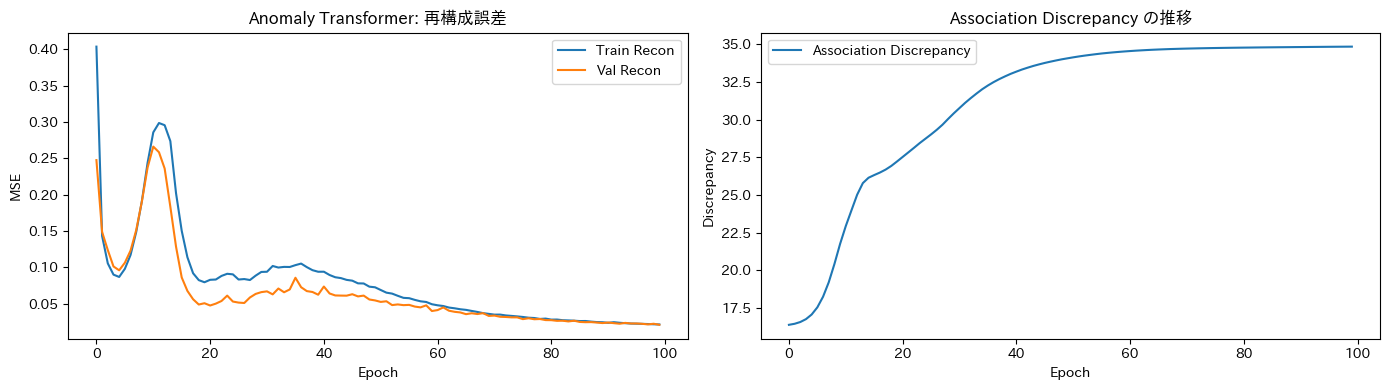

In [5]:
def kl_divergence(p, q):
    """KL(P || Q) per position"""
    return (p * (torch.log(p + 1e-8) - torch.log(q + 1e-8))).sum(dim=-1)

model_at = AnomalyTransformerModel(
    n_features=len(ae_features), d_model=64, n_heads=4, n_layers=3,
    seq_len=T_PATCH, d_ff=256, dropout=0.1
).to(device)
optimizer_at = torch.optim.Adam(model_at.parameters(), lr=1e-4)
lambda_disc = 3.0

train_losses_at = []
val_losses_at = []
disc_history = []

for epoch in range(100):
    model_at.train()
    epoch_recon = 0
    epoch_disc = 0

    for (batch,) in t_train_loader:
        batch = batch.to(device)

        # Phase 1: Minimize (reconstruction + minimize discrepancy)
        output, series, prior = model_at(batch)
        recon_loss = nn.functional.mse_loss(output, batch)
        disc_min = 0
        for s, p in zip(series, prior):
            disc_min += kl_divergence(s, p.detach()).mean() + kl_divergence(p.detach(), s).mean()
        disc_min = disc_min / len(series)
        loss_min = recon_loss - lambda_disc * disc_min
        optimizer_at.zero_grad()
        loss_min.backward()
        nn.utils.clip_grad_norm_(model_at.parameters(), 1.0)
        optimizer_at.step()

        # Phase 2: Maximize (maximize discrepancy)
        output, series, prior = model_at(batch)
        disc_max = 0
        for s, p in zip(series, prior):
            disc_max += kl_divergence(s.detach(), p).mean() + kl_divergence(p, s.detach()).mean()
        disc_max = disc_max / len(series)
        loss_max = lambda_disc * disc_max
        optimizer_at.zero_grad()
        loss_max.backward()
        nn.utils.clip_grad_norm_(model_at.parameters(), 1.0)
        optimizer_at.step()

        epoch_recon += recon_loss.item() * len(batch)
        epoch_disc += disc_min.item() * len(batch)

    train_losses_at.append(epoch_recon / len(t_train))
    disc_history.append(epoch_disc / len(t_train))

    # Validation
    model_at.eval()
    val_loss = 0
    with torch.no_grad():
        for (batch,) in t_val_loader:
            batch = batch.to(device)
            output, _, _ = model_at(batch)
            val_loss += nn.functional.mse_loss(output, batch).item() * len(batch)
    val_losses_at.append(val_loss / len(t_val))

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/100 - Recon: {train_losses_at[-1]:.6f}, Val: {val_losses_at[-1]:.6f}, Disc: {disc_history[-1]:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(train_losses_at, label='Train Recon')
axes[0].plot(val_losses_at, label='Val Recon')
axes[0].set(xlabel='Epoch', ylabel='MSE', title='Anomaly Transformer: 再構成誤差')
axes[0].legend()
axes[1].plot(disc_history, label='Association Discrepancy')
axes[1].set(xlabel='Epoch', ylabel='Discrepancy', title='Association Discrepancy の推移')
axes[1].legend()
plt.tight_layout()
plt.show()

## 1-3. 異常スコア計算と可視化

Anomaly Transformer 閾値(95%ile): 0.000403
異常ポイント数: 1770 (5.00%)

Discrepancy比 (異常/正常): 83.11 (目標: 2以上)


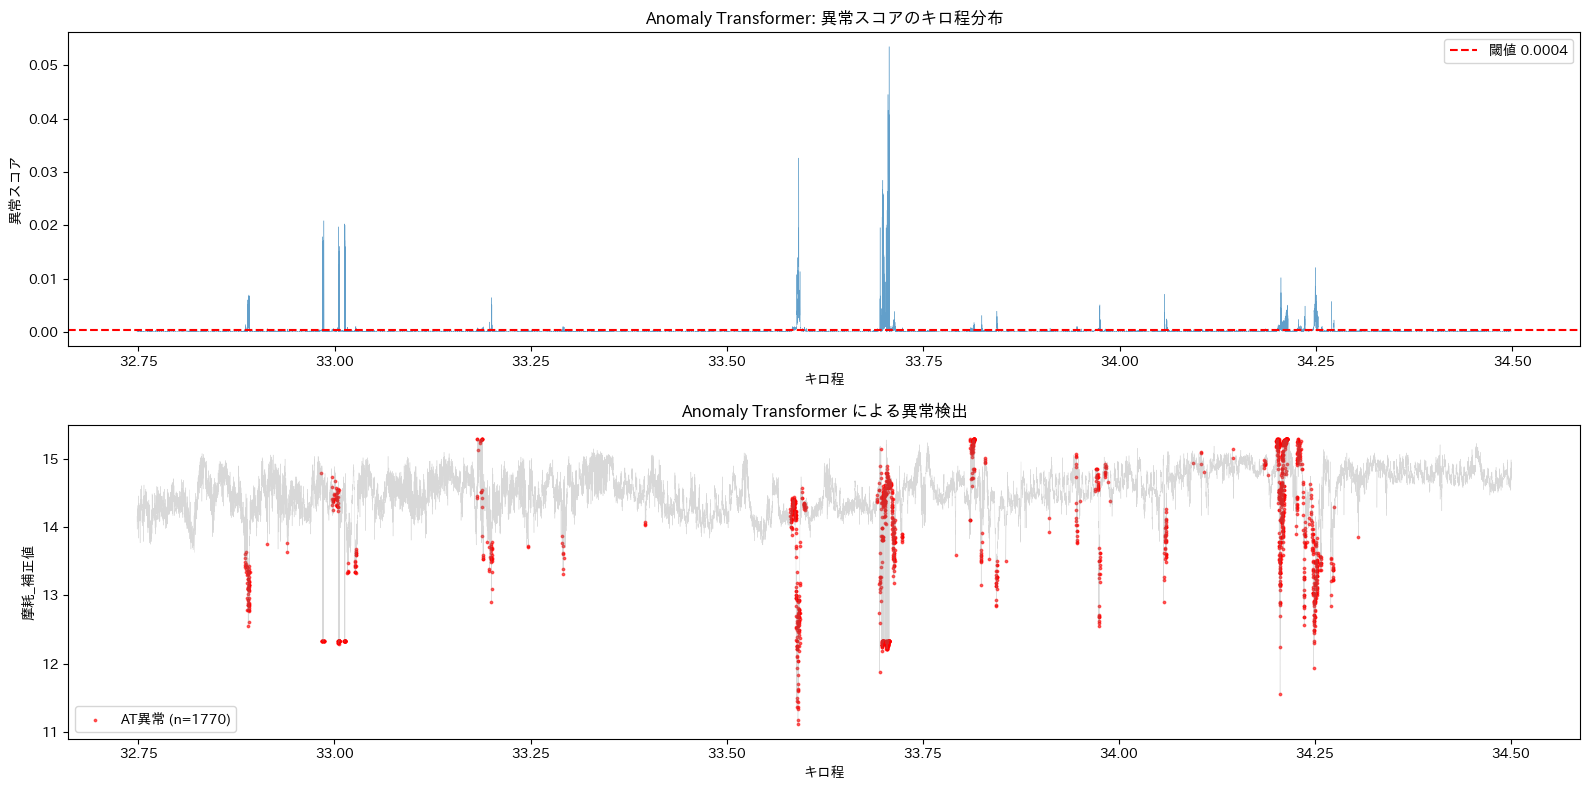

In [6]:
# 異常スコア計算: softmax(discrepancy) * reconstruction_error
model_at.eval()
at_patch_scores = []

with torch.no_grad():
    for (batch,) in t_all_loader:
        batch = batch.to(device)
        output, series, prior = model_at(batch)

        # Reconstruction error per time step
        recon_err = ((batch - output) ** 2).mean(dim=-1)  # (B, L)

        # Association Discrepancy per time step
        disc = torch.zeros(batch.shape[0], batch.shape[1], device=device)
        for s, p in zip(series, prior):
            kl1 = kl_divergence(s, p)  # (B, H, L)
            kl2 = kl_divergence(p, s)
            disc += (kl1 + kl2).mean(dim=1)  # head平均
        disc /= len(series)

        # 最終スコア
        disc_norm = torch.softmax(disc, dim=-1)
        anomaly_score = disc_norm * recon_err  # (B, L)
        at_patch_scores.extend(anomaly_score.cpu().numpy())

at_patch_scores = np.array(at_patch_scores)

# ポイントレベル展開
data['at_anomaly_score'] = np.nan
point_scores_at = np.full(len(data), np.nan)
point_counts_at = np.zeros(len(data))

for i, start_idx in enumerate(range(0, len(ae_data_scaled) - T_PATCH + 1, T_STRIDE)):
    for j in range(T_PATCH):
        idx = start_idx + j
        if idx < len(data):
            if np.isnan(point_scores_at[idx]):
                point_scores_at[idx] = 0
            point_scores_at[idx] += at_patch_scores[i][j]
            point_counts_at[idx] += 1

valid = point_counts_at > 0
data.loc[data.index[valid], 'at_anomaly_score'] = point_scores_at[valid] / point_counts_at[valid]

# 閾値: 95パーセンタイル
threshold_at = data['at_anomaly_score'].quantile(0.95)
data['anomaly_at'] = data['at_anomaly_score'] > threshold_at
n_at = data['anomaly_at'].sum()
print(f"Anomaly Transformer 閾値(95%ile): {threshold_at:.6f}")
print(f"異常ポイント数: {n_at} ({n_at/len(data)*100:.2f}%)")

# lambda_disc 調整基準の確認: 正常/異常パッチのdiscrepancy比
normal_scores = data.loc[~data['consensus_anomaly'], 'at_anomaly_score'].dropna()
anomaly_scores = data.loc[data['consensus_anomaly'], 'at_anomaly_score'].dropna()
disc_ratio = anomaly_scores.mean() / normal_scores.mean() if normal_scores.mean() > 0 else float('inf')
print(f"\nDiscrepancy比 (異常/正常): {disc_ratio:.2f} (目標: 2以上)")

# 可視化
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
axes[0].plot(data['キロ程'], data['at_anomaly_score'], linewidth=0.3, alpha=0.7)
axes[0].axhline(y=threshold_at, color='red', linestyle='--', label=f'閾値 {threshold_at:.4f}')
axes[0].set(xlabel='キロ程', ylabel='異常スコア', title='Anomaly Transformer: 異常スコアのキロ程分布')
axes[0].legend()

mask_at = data['anomaly_at']
axes[1].plot(data['キロ程'], data['摩耗_補正値'], linewidth=0.3, alpha=0.3, color='gray')
axes[1].scatter(data.loc[mask_at, 'キロ程'], data.loc[mask_at, '摩耗_補正値'],
               c='red', s=3, alpha=0.6, label=f'AT異常 (n={n_at})')
axes[1].set(xlabel='キロ程', ylabel='摩耗_補正値', title='Anomaly Transformer による異常検出')
axes[1].legend()
plt.tight_layout()
plt.show()

# Step 2: 時系列Foundation Model (Chronos)

Amazon Chronos をゼロショットで適用。予測残差ベースの異常検出。

In [ ]:
from chronos import ChronosPipeline

pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",  # MPS未対応の場合はCPU
    dtype=torch.float32,
)

CONTEXT_LEN = 512
PREDICTION_LEN = 64
STEP = 64

wear_series = torch.FloatTensor(data['摩耗_補正値'].ffill().bfill().values)
n_windows = (len(wear_series) - CONTEXT_LEN - PREDICTION_LEN) // STEP + 1
print(f"ウィンドウ数: {n_windows}, 推定処理時間は実行して確認")

'(ProtocolError('Connection aborted.', ConnectionResetError(54, 'Connection reset by peer')), '(Request ID: af45797a-bbfa-47fb-9c53-2cb67b7ba50e)')' thrown while requesting HEAD https://huggingface.co/amazon/chronos-t5-small/resolve/main/config.json
Retrying in 1s [Retry 1/5].


In [ ]:
# Chronos予測残差の計算
chronos_scores = np.full(len(data), np.nan)

for start in tqdm(range(0, len(wear_series) - CONTEXT_LEN - PREDICTION_LEN, STEP),
                  desc="Chronos推論", total=n_windows):
    context = wear_series[start:start + CONTEXT_LEN]
    actual = wear_series[start + CONTEXT_LEN:start + CONTEXT_LEN + PREDICTION_LEN].numpy()

    forecast = pipeline.predict(
        context.unsqueeze(0),
        prediction_length=PREDICTION_LEN,
        num_samples=20,
    )

    median_pred = forecast.median(dim=1).values[0].numpy()
    q10 = np.quantile(forecast[0].numpy(), 0.1, axis=0)
    q90 = np.quantile(forecast[0].numpy(), 0.9, axis=0)

    pred_std = np.clip((q90 - q10) / 2.56, 1e-6, None)
    residual = np.abs(actual - median_pred) / pred_std

    for j in range(PREDICTION_LEN):
        idx = start + CONTEXT_LEN + j
        if idx < len(data):
            if np.isnan(chronos_scores[idx]):
                chronos_scores[idx] = residual[j]
            else:
                chronos_scores[idx] = max(chronos_scores[idx], residual[j])

data['chronos_score'] = chronos_scores
print(f"Chronosスコア計算完了: {(~np.isnan(chronos_scores)).sum()} 点にスコア付与")

In [ ]:
# 閾値の決定: まず分布を可視化
valid_scores = data['chronos_score'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(valid_scores, bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(x=3.0, color='red', linestyle='--', label='閾値候補 3.0')
axes[0].set(xlabel='正規化残差', ylabel='頻度', title='Chronos: 正規化残差の分布')
axes[0].legend()

# パーセンタイル確認
for p in [90, 95, 97.5, 99]:
    val = valid_scores.quantile(p / 100)
    print(f"{p}パーセンタイル: {val:.4f}")

# 97.5パーセンタイルを閾値として採用（分布を見て調整可能）
threshold_chronos = valid_scores.quantile(0.975)
data['anomaly_chronos'] = data['chronos_score'] > threshold_chronos
n_chronos = data['anomaly_chronos'].sum()
print(f"\n採用閾値 (97.5%ile): {threshold_chronos:.4f}")
print(f"Chronos異常ポイント数: {n_chronos} ({n_chronos/len(data)*100:.2f}%)")

mask_chronos = data['anomaly_chronos']
axes[1].plot(data['キロ程'], data['摩耗_補正値'], linewidth=0.3, alpha=0.3, color='gray')
axes[1].scatter(data.loc[mask_chronos, 'キロ程'], data.loc[mask_chronos, '摩耗_補正値'],
               c='red', s=3, alpha=0.6, label=f'Chronos異常 (n={n_chronos})')
axes[1].set(xlabel='キロ程', ylabel='摩耗_補正値', title='Chronos による異常検出')
axes[1].legend()
plt.tight_layout()
plt.show()

# Step 3: LLMによる異常分類 (Amazon Bedrock + Claude Haiku 4.5)

検出された異常区間の数値プロファイルをClaude Haikuに送り、異常の種類を分類する。

分類カテゴリ:
- **local_wear**: 真の局部摩耗
- **measurement_noise**: 計測ノイズ
- **structural_wear**: 構造的摩耗（架線構造変化点）
- **uncertain**: 不確実

In [ ]:
import boto3

bedrock = boto3.client('bedrock-runtime', region_name='us-east-1')
MODEL_ID = "us.anthropic.claude-haiku-4-5-20251001"

# 異常区間の再構築（Phase 1と同じロジック）
anomaly_indices = data.index[data['consensus_anomaly']].tolist()
segments = []
if len(anomaly_indices) > 0:
    seg_start = anomaly_indices[0]
    seg_end = anomaly_indices[0]
    for idx in anomaly_indices[1:]:
        if idx - seg_end <= 5:
            seg_end = idx
        else:
            segments.append((seg_start, seg_end))
            seg_start = idx
            seg_end = idx
    segments.append((seg_start, seg_end))
print(f"異常区間数: {len(segments)}")


def create_anomaly_profile(seg_start, seg_end, context_margin=50):
    """異常区間の数値プロファイルをJSON化"""
    seg = data.loc[seg_start:seg_end]
    ctx_start = max(data.index[0], seg_start - context_margin)
    ctx_end = min(data.index[-1], seg_end + context_margin)
    context = data.loc[ctx_start:ctx_end]

    return {
        'キロ程範囲': f"{seg['キロ程'].iloc[0]:.5f} - {seg['キロ程'].iloc[-1]:.5f}",
        '区間長_m': round((seg['キロ程'].iloc[-1] - seg['キロ程'].iloc[0]) * 1000, 1),
        'ポイント数': len(seg),
        '架線構造': seg['架線構造名'].mode().iloc[0] if len(seg) > 0 else '',
        'トロリ線種': seg['トロリ線種'].mode().iloc[0] if len(seg) > 0 else '',
        '摩耗_区間': {
            'min': round(float(seg['摩耗_補正値'].min()), 3),
            'mean': round(float(seg['摩耗_補正値'].mean()), 3),
            'max': round(float(seg['摩耗_補正値'].max()), 3),
            'std': round(float(seg['摩耗_補正値'].std()), 3),
        },
        '摩耗_周辺mean': round(float(context['摩耗_補正値'].mean()), 3),
        '周辺との乖離': round(float(seg['摩耗_補正値'].mean() - context['摩耗_補正値'].mean()), 3),
        '勾配_max': round(float(seg['gradient_local'].abs().max()), 4),
        '変動係数': round(float(seg['摩耗_補正値'].std() / max(seg['摩耗_補正値'].mean(), 1e-6)), 4),
        '合意手法数_max': int(seg['total_vote_count'].max()),
        '摩耗値系列': seg['摩耗_補正値'].iloc[::max(1, len(seg)//20)].round(3).tolist(),
    }

# テスト: 最初の区間のプロファイル
profile_test = create_anomaly_profile(*segments[0])
print(json.dumps(profile_test, ensure_ascii=False, indent=2))

In [ ]:
ZERO_SHOT_PROMPT = """あなたは鉄道設備の保守専門家です。トロリ線（架線）の摩耗計測データにおける異常区間の分類を行ってください。

## 背景知識
- トロリ線の残存直径は新品で約12.3mm、交換基準は約8.5mm
- 5cm間隔で計測されたデータ
- 摩耗_補正値が小さいほど摩耗が進んでいる
- 計測エラー（偽陰性）は前処理で補正済み

## 異常の種類
1. **local_wear**: 真の局部摩耗。物理的原因による局所的な摩耗進行。周辺より一貫して摩耗が進行し、変動係数が比較的小さい。
2. **measurement_noise**: 計測ノイズ。1-2点のスパイク、前後との不整合。変動係数が大きい。
3. **structural_wear**: 構造的摩耗。架線構造の変化点付近での段差。区間の境界に位置し、急激な変化がある。
4. **uncertain**: 上記のいずれとも確信を持てない場合。

## 判定対象の異常区間
{profile_json}

## 回答形式
以下のJSON形式のみで回答してください。説明文は不要です。
```json
{{"classification": "local_wear|measurement_noise|structural_wear|uncertain", "confidence": 0.0-1.0, "reasoning": "判定理由（1-2文）"}}
```"""


def classify_anomaly_with_llm(profile, max_retries=2):
    """Bedrock経由でClaude Haikuに分類させる"""
    prompt = ZERO_SHOT_PROMPT.format(
        profile_json=json.dumps(profile, ensure_ascii=False, indent=2)
    )

    for attempt in range(max_retries):
        try:
            response = bedrock.converse(
                modelId=MODEL_ID,
                messages=[{"role": "user", "content": [{"text": prompt}]}],
                inferenceConfig={"temperature": 0.0, "maxTokens": 300},
            )
            text = response['output']['message']['content'][0]['text']
            # JSONブロックを抽出
            if '```json' in text:
                text = text.split('```json')[1].split('```')[0].strip()
            elif '```' in text:
                text = text.split('```')[1].split('```')[0].strip()
            return json.loads(text)
        except (json.JSONDecodeError, KeyError, Exception) as e:
            if attempt < max_retries - 1:
                time.sleep(1.0 * (attempt + 1))
                continue
            print(f"  パース失敗 (attempt {attempt+1}): {e}")
            return {"classification": "uncertain", "confidence": 0.0, "reasoning": "API/パースエラー"}

# 全区間を分類
llm_results = []
for i, (start, end) in enumerate(tqdm(segments, desc="LLM分類")):
    profile = create_anomaly_profile(start, end)
    result = classify_anomaly_with_llm(profile)
    result['segment_id'] = i
    result['seg_start'] = start
    result['seg_end'] = end
    llm_results.append(result)
    time.sleep(0.5)

df_llm = pd.DataFrame(llm_results)
print(f"\n=== LLM分類結果サマリー ===")
print(df_llm['classification'].value_counts())
print(f"\n平均confidence: {df_llm['confidence'].mean():.3f}")

In [ ]:
# LLM分類結果の可視化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 分類分布
class_counts = df_llm['classification'].value_counts()
colors_map = {'local_wear': '#d62728', 'measurement_noise': '#ff7f0e',
              'structural_wear': '#2ca02c', 'uncertain': '#7f7f7f'}
colors = [colors_map.get(c, '#333') for c in class_counts.index]
axes[0].bar(class_counts.index, class_counts.values, color=colors)
axes[0].set(xlabel='分類', ylabel='区間数', title='LLM分類結果の分布')
axes[0].tick_params(axis='x', rotation=30)

# Confidence分布
for cls in df_llm['classification'].unique():
    subset = df_llm[df_llm['classification'] == cls]
    axes[1].hist(subset['confidence'], bins=10, alpha=0.6, label=cls,
                color=colors_map.get(cls, '#333'))
axes[1].set(xlabel='Confidence', ylabel='頻度', title='分類別Confidence分布')
axes[1].legend(fontsize=8)

# 空間分布: 分類結果をキロ程上にプロット
axes[2].plot(data['キロ程'], data['摩耗_補正値'], linewidth=0.3, alpha=0.2, color='gray')
for _, row in df_llm.iterrows():
    seg = data.loc[row['seg_start']:row['seg_end']]
    color = colors_map.get(row['classification'], '#333')
    axes[2].scatter(seg['キロ程'], seg['摩耗_補正値'], c=color, s=3, alpha=0.7)
# 凡例
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, markersize=8, label=k)
                   for k, v in colors_map.items()]
axes[2].legend(handles=legend_elements, fontsize=8)
axes[2].set(xlabel='キロ程', ylabel='摩耗_補正値', title='LLM分類結果の空間分布')
plt.tight_layout()
plt.show()

# 詳細テーブル表示
print("\n=== 分類詳細 ===")
for _, row in df_llm.iterrows():
    seg = data.loc[row['seg_start']:row['seg_end']]
    kilo_range = f"{seg['キロ程'].iloc[0]:.5f}-{seg['キロ程'].iloc[-1]:.5f}"
    print(f"区間{row['segment_id']:2d}: {kilo_range} | {row['classification']:20s} "
          f"(conf={row['confidence']:.2f}) | {row['reasoning']}")

# Step 4: 教師あり学習（保留）

正解データ未入手のため、データ読み込みインターフェースとメタ分類器のスケルトンのみ実装。
正解ラベルが入手でき次第、このセルを有効化して実行する。

In [ ]:
# === 教師あり学習スケルトン（正解データ投入後に実行） ===
# このセルは正解データが入手できるまでスキップ

GROUND_TRUTH_PATH = 'data/ground_truth.csv'  # 正解ラベルファイルのパスを変更

import os
if os.path.exists(GROUND_TRUTH_PATH):
    from xgboost import XGBClassifier
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import (average_precision_score, precision_score,
                                 recall_score, f1_score, classification_report)

    # 正解データ読み込み
    gt = pd.read_csv(GROUND_TRUTH_PATH)
    # TODO: 正解データのカラム名に応じてマッピングを調整
    # data['label'] = gt['label'] のようにマージ

    # メタ特徴量の構築
    meta_features = [
        '摩耗_補正値', 'diff_from_local', 'rolling_std_1m', 'gradient_local',
        'total_vote_count', 'at_anomaly_score', 'chronos_score',
    ]

    X = data[meta_features].fillna(0).values
    y = data['label'].values  # 正解ラベル

    # LLM分類結果をone-hot化してメタ特徴量に追加
    # （LLM分類はポイントではなく区間単位なので、区間→ポイントにマッピング）
    for cls in ['local_wear', 'measurement_noise', 'structural_wear', 'uncertain']:
        data[f'llm_{cls}'] = 0.0
    for _, row in df_llm.iterrows():
        cls = row['classification']
        conf = row['confidence']
        data.loc[row['seg_start']:row['seg_end'], f'llm_{cls}'] = conf

    llm_features = [f'llm_{c}' for c in ['local_wear', 'measurement_noise', 'structural_wear', 'uncertain']]
    X_full = np.hstack([X, data[llm_features].values])
    meta_features_full = meta_features + llm_features

    # XGBoost with 5-fold Stratified CV
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_results = []

    pos_ratio = y.sum() / len(y)
    scale_pos = (1 - pos_ratio) / max(pos_ratio, 1e-6)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, y)):
        clf = XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            scale_pos_weight=scale_pos, random_state=42, eval_metric='aucpr',
        )
        clf.fit(X_full[train_idx], y[train_idx],
                eval_set=[(X_full[val_idx], y[val_idx])], verbose=False)
        y_pred = clf.predict(X_full[val_idx])
        y_prob = clf.predict_proba(X_full[val_idx])[:, 1]

        cv_results.append({
            'fold': fold,
            'auc_pr': average_precision_score(y[val_idx], y_prob),
            'precision': precision_score(y[val_idx], y_pred),
            'recall': recall_score(y[val_idx], y_pred),
            'f1': f1_score(y[val_idx], y_pred),
        })

    df_cv = pd.DataFrame(cv_results)
    print("=== XGBoost 5-Fold CV 結果 ===")
    print(df_cv.to_string(index=False))
    print(f"\n平均 AUC-PR: {df_cv['auc_pr'].mean():.4f} ± {df_cv['auc_pr'].std():.4f}")
    print(f"平均 F1:     {df_cv['f1'].mean():.4f} ± {df_cv['f1'].std():.4f}")
else:
    print(f"正解データファイル '{GROUND_TRUTH_PATH}' が見つかりません。")
    print("正解データが入手でき次第、GROUND_TRUTH_PATHを更新してこのセルを実行してください。")

# Step 5: 統合評価

Phase 1 (11手法) + Phase 2 (Anomaly Transformer, Chronos) = **13手法**の統合コンセンサス。
LLM分類結果とのクロス集計、全手法の最終比較表を作成する。

In [ ]:
# 13手法の統合コンセンサス
phase2_methods = {
    'anomaly_transformer': 'anomaly_at',
    'chronos': 'anomaly_chronos',
}

# Phase 1 + Phase 2 の全手法
all_methods_combined = {**all_anomaly_methods, **phase2_methods}
print(f"全手法数: {len(all_methods_combined)}")
for name, col in all_methods_combined.items():
    n = data[col].sum() if col in data.columns else 0
    print(f"  {name:30s}: {n:5d} 点 ({n/len(data)*100:.2f}%)")

# 13手法での投票数
data['total_vote_13'] = sum(
    data[col].astype(int) for col in all_methods_combined.values() if col in data.columns
)

# コンセンサス閾値: 7手法(ceil(13*0.55)=8も候補)
for threshold in [7, 8]:
    col_name = f'consensus_13_{threshold}'
    data[col_name] = data['total_vote_13'] >= threshold
    n = data[col_name].sum()
    print(f"\n13手法コンセンサス (閾値={threshold}): {n} 点 ({n/len(data)*100:.2f}%)")

# Phase 1コンセンサスとの比較
print(f"\nPhase 1 コンセンサス (6+/11手法): {data['consensus_anomaly'].sum()} 点")
overlap_7 = (data['consensus_anomaly'] & data['consensus_13_7']).sum()
overlap_8 = (data['consensus_anomaly'] & data['consensus_13_8']).sum()
print(f"Phase 1 ∩ 13手法(7+): {overlap_7} 点")
print(f"Phase 1 ∩ 13手法(8+): {overlap_8} 点")
only_p1 = (data['consensus_anomaly'] & ~data['consensus_13_7']).sum()
only_p2 = (~data['consensus_anomaly'] & data['consensus_13_7']).sum()
print(f"Phase 1のみ: {only_p1} 点, Phase 2で新規追加: {only_p2} 点")

In [ ]:
# LLM分類結果 × コンセンサス強度のクロス集計
# 各異常区間のコンセンサス強度（13手法投票数の最大値）をマッピング
df_llm['max_vote_13'] = [
    data.loc[row['seg_start']:row['seg_end'], 'total_vote_13'].max()
    for _, row in df_llm.iterrows()
]
df_llm['vote_band'] = pd.cut(df_llm['max_vote_13'], bins=[0, 6, 8, 10, 13],
                              labels=['1-6', '7-8', '9-10', '11-13'])

cross_tab = pd.crosstab(df_llm['classification'], df_llm['vote_band'], margins=True)
print("=== LLM分類 × コンセンサス強度 クロス集計 ===")
print(cross_tab)

# ヒートマップ
fig, ax = plt.subplots(figsize=(8, 5))
cross_no_margin = pd.crosstab(df_llm['classification'], df_llm['vote_band'])
sns.heatmap(cross_no_margin, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set(xlabel='コンセンサス強度 (13手法投票数)', ylabel='LLM分類',
       title='LLM分類 × コンセンサス強度')
plt.tight_layout()
plt.show()

In [ ]:
# 全手法の最終比較表
method_summary = []
for name, col in all_methods_combined.items():
    if col not in data.columns:
        continue
    n_anom = data[col].sum()
    # Phase 1コンセンサスとの一致率
    overlap = (data[col] & data['consensus_anomaly']).sum()
    precision_vs_consensus = overlap / max(n_anom, 1)
    recall_vs_consensus = overlap / max(data['consensus_anomaly'].sum(), 1)
    method_summary.append({
        '手法': name,
        '異常数': int(n_anom),
        '検出率(%)': round(n_anom / len(data) * 100, 2),
        'コンセンサス一致率(P)': round(precision_vs_consensus, 3),
        'コンセンサス再現率(R)': round(recall_vs_consensus, 3),
    })

df_summary = pd.DataFrame(method_summary).sort_values('コンセンサス一致率(P)', ascending=False)
print("=== 全13手法の最終比較表 ===")
print(df_summary.to_string(index=False))

# 棒グラフ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df_plot = df_summary.sort_values('検出率(%)')
axes[0].barh(df_plot['手法'], df_plot['検出率(%)'], color='steelblue')
axes[0].set(xlabel='検出率 (%)', title='手法別 異常検出率')

axes[1].barh(df_plot['手法'], df_plot['コンセンサス一致率(P)'], color='coral', label='一致率(P)')
axes[1].barh(df_plot['手法'], df_plot['コンセンサス再現率(R)'], color='steelblue',
             alpha=0.5, label='再現率(R)')
axes[1].set(xlabel='スコア', title='Phase 1 コンセンサスとの一致率/再現率')
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
# 13手法コンセンサスの空間分布（最終可視化）
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

# (1) 摩耗値と13手法コンセンサス (7+)
axes[0].plot(data['キロ程'], data['摩耗_補正値'], linewidth=0.3, alpha=0.3, color='gray')
mask7 = data['consensus_13_7']
axes[0].scatter(data.loc[mask7, 'キロ程'], data.loc[mask7, '摩耗_補正値'],
               c='red', s=3, alpha=0.6, label=f'コンセンサス 7+/13 (n={mask7.sum()})')
axes[0].set(ylabel='摩耗_補正値', title='13手法コンセンサス (閾値=7)')
axes[0].legend()

# (2) 投票数ヒートマップ
axes[1].scatter(data['キロ程'], [0]*len(data), c=data['total_vote_13'],
               cmap='YlOrRd', s=1, vmin=0, vmax=13)
axes[1].set(ylabel='', title='13手法投票数マップ')
axes[1].set_yticks([])
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=plt.Normalize(0, 13))
plt.colorbar(sm, ax=axes[1], label='投票数')

# (3) LLM分類結果の空間マッピング
colors_map = {'local_wear': '#d62728', 'measurement_noise': '#ff7f0e',
              'structural_wear': '#2ca02c', 'uncertain': '#7f7f7f'}
axes[2].plot(data['キロ程'], data['摩耗_補正値'], linewidth=0.3, alpha=0.2, color='gray')
for _, row in df_llm.iterrows():
    seg = data.loc[row['seg_start']:row['seg_end']]
    color = colors_map.get(row['classification'], '#333')
    axes[2].scatter(seg['キロ程'], seg['摩耗_補正値'], c=color, s=5, alpha=0.8)
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, markersize=8, label=k)
                   for k, v in colors_map.items()]
axes[2].legend(handles=legend_elements, fontsize=8)
axes[2].set(xlabel='キロ程', ylabel='摩耗_補正値', title='LLM分類結果マッピング')

plt.tight_layout()
plt.show()

print("\n=== Phase 2 分析完了 ===")
print(f"Phase 1: 11手法, Phase 2: +2手法 = 計13手法")
print(f"コンセンサス (7+/13): {data['consensus_13_7'].sum()} 点")
print(f"コンセンサス (8+/13): {data['consensus_13_8'].sum()} 点")
print(f"LLM分類済み区間: {len(df_llm)} 区間")
print(f"  local_wear: {(df_llm['classification']=='local_wear').sum()}")
print(f"  measurement_noise: {(df_llm['classification']=='measurement_noise').sum()}")
print(f"  structural_wear: {(df_llm['classification']=='structural_wear').sum()}")
print(f"  uncertain: {(df_llm['classification']=='uncertain').sum()}")
print(f"\n教師あり学習: 正解データ入手待ち（Step 4のセルを実行）")